In [124]:
import pandas as pd
import datetime as dt
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
import warnings

In [125]:
start = dt.datetime(2021, 7, 1)
end = dt.datetime(2022, 1, 27)

symbol = "INFY.NS"
stockData = yf.download(symbol, start=start, end=end)
stockData.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2021-07-01,1359.065552,1373.393007,1357.889760,1373.393007,4814317
2021-07-02,1365.510742,1366.947762,1343.562171,1357.802550,5166064
2021-07-05,1375.222168,1380.491595,1359.631843,1366.686700,4058338
2021-07-06,1360.633179,1382.015596,1356.191240,1370.649362,4089574
2021-07-07,1362.723755,1367.906106,1345.347893,1363.986729,4797120


In [126]:
stockData = stockData[["Open", "High", "Low", "Close"]]

stockData.head()

Price,Open,High,Low,Close
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,
2021-07-01,1373.393007,1373.393007,1357.889760,1359.065552
2021-07-02,1357.802550,1366.947762,1343.562171,1365.510742
2021-07-05,1366.686700,1380.491595,1359.631843,1375.222168
2021-07-06,1370.649362,1382.015596,1356.191240,1360.633179
2021-07-07,1363.986729,1367.906106,1345.347893,1362.723755


In [127]:
column = "Close"

Ms = MinMaxScaler()
data1 = Ms.fit_transform(stockData[[column]])

print("Len:", data1.shape)

Len: (143, 1)


In [128]:
training_size = round(len(data1) * 0.90)

print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]

print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]

print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

warnings.filterwarnings("ignore")

129
X_train length: (129, 1)
X_test length: (14, 1)
y_train length: (129, 1)
y_test length: (14, 1)


In [129]:
def rmsemape(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print("RMSE:", round(rmse, 4))
    print("MAPE:", round(mape, 4), "%")
    return rmse, mape


def conversionSingle(values, columns):
    arr = np.array(values).reshape(-1, 1)
    return pd.DataFrame(arr, columns=columns)


def graph(y_true, y_pred, label1, label2, title, xlabel, ylabel):
    plt.figure(figsize=(10, 6))
    plt.plot(y_true, label=label1)
    plt.plot(y_pred, label=label2)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [130]:
trends = ["n", "t", "c", "ct"]
orders = [(0, 0, 10)]

for td in trends:
    model = ARIMA(X_train.flatten(), order=(0, 0, 10), trend=td)
    model_fit = model.fit()
    y_pred = model_fit.predict(start=len(X_train), end=len(data1) - 1)
    
    mse, mape = rmsemape(y_test, y_pred)
    print("Trend={} - RMSE: {:.2f}, MAPE: {:.2f}%".format(td, mse, mape))
    print("************")

RMSE: 0.666
MAPE: 76.9355 %
Trend=n - RMSE: 0.67, MAPE: 76.94%
************
RMSE: 0.1824
MAPE: 21.6035 %
Trend=t - RMSE: 0.18, MAPE: 21.60%
************
RMSE: 0.3173
MAPE: 30.9883 %
Trend=c - RMSE: 0.32, MAPE: 30.99%
************
RMSE: 0.1744
MAPE: 20.6354 %
Trend=ct - RMSE: 0.17, MAPE: 20.64%
************


In [131]:
td = "c"

model = ARIMA(X_train.flatten(), order=(0, 0, 20), trend=td)
model_fit = model.fit()

y_pred = model_fit.predict(start=len(X_train), end=len(data1) - 1)

mse, mape = rmsemape(y_test, y_pred)
print("Trend={} - RMSE: {:.2f}, MAPE: {:.2f}%".format(td, mse, mape))
print("************")

RMSE: 0.265
MAPE: 25.5331 %
Trend=c - RMSE: 0.26, MAPE: 25.53%
************


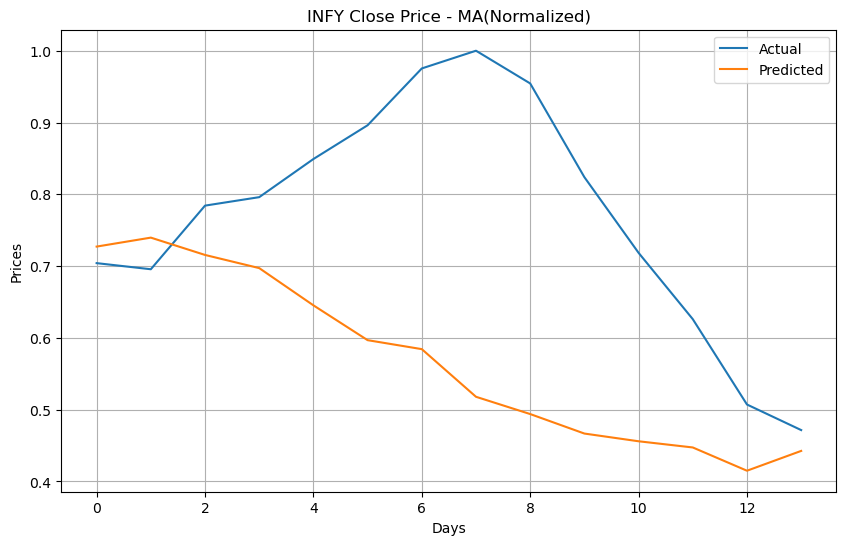

In [132]:
plt.figure(figsize=(10, 6))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.xlabel("Days")
plt.ylabel("Prices")
plt.title("INFY Close Price - MA(Normalized)")
plt.legend()
plt.grid(True)
plt.show()

In [133]:
len(data1)

143

In [134]:
aTestNormTable = pd.DataFrame({"Close": np.array(y_test).flatten()})
print(aTestNormTable.head())

actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA = pd.DataFrame({"Close": actual_stock_price_test_ori.flatten()})

actual_stock_price_test_oriA.head()

      Close
0  0.704140
1  0.695631
2  0.784243
3  0.796034
4  0.849153


,Close
0,1597.285278
1,1594.209717
2,1626.238159
3,1630.499634
4,1649.699219


In [135]:
y_pred_series = pd.Series(np.array(y_pred).flatten())
pTestNormTable = pd.DataFrame({"Close": y_pred_series})

predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP = pd.DataFrame({"Close": predicted_stock_price_test_ori.flatten()})

predicted_stock_price_test_oriP.head()

,Close
0,1605.618261
1,1610.127336
2,1601.410019
3,1594.784640
4,1576.040787


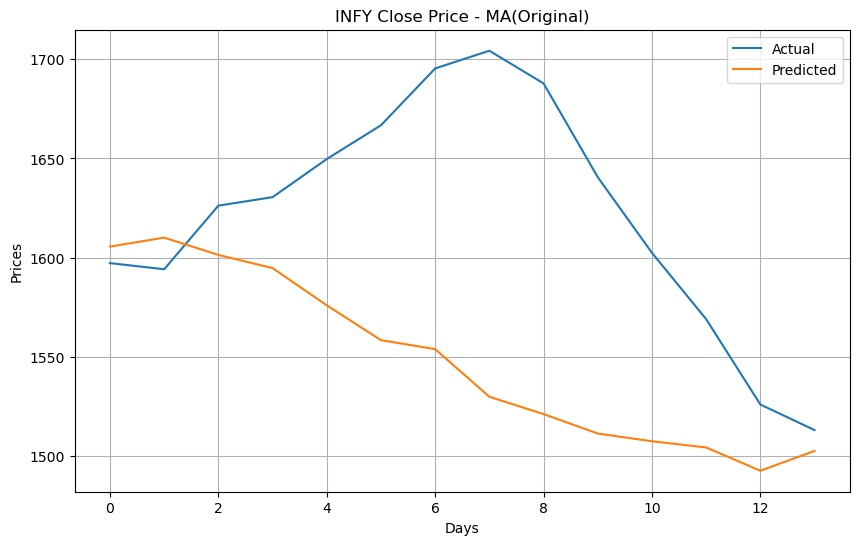

In [136]:
plt.figure(figsize=(10, 6))
plt.plot(actual_stock_price_test_oriA, label="Actual")
plt.plot(predicted_stock_price_test_oriP, label="Predicted")
plt.xlabel("Days")
plt.ylabel("Prices")
plt.title("INFY Close Price - MA(Original)")
plt.legend()
plt.grid(True)
plt.show()

In [137]:
rmse, mape = rmsemape(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)

RMSE: 95.777
MAPE: 4.6711 %


In [138]:
forecast = model_fit.predict(len(data1), len(data1) + 3)
forecast

array([0.45872106, 0.42932927, 0.40856933, 0.39187622])

In [139]:
fTestNormTable = pd.DataFrame({"Closefore": forecast})

forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF = pd.DataFrame({"Closefore": forecast_stock_price_test_ori[:, 0]})

forecast_stock_price_test_oriF

,Closefore
0,1508.580105
1,1497.956621
2,1490.453067
3,1484.419446


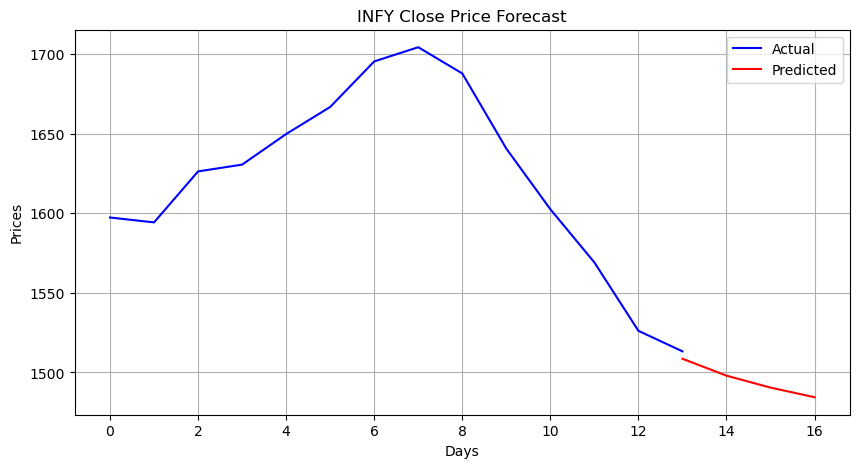

In [140]:
plt.figure(figsize=(10, 5))
plt.plot(actual_stock_price_test_oriA.iloc[-50:], color="blue", label="Actual")
plt.plot(
    range(len(actual_stock_price_test_oriA) - 1, len(actual_stock_price_test_oriA) - 1 + len(forecast_stock_price_test_oriF)),
    forecast_stock_price_test_oriF["Closefore"],
    color="red",
    label="Predicted"
)
plt.xlabel("Days")
plt.ylabel("Prices")
plt.title("INFY Close Price Forecast")
plt.legend()
plt.grid(True)
plt.show()

In [141]:
forecast_stock_price_test_oriF.to_csv("CloseMA_INFY.csv", index=False)
print("Forecast saved successfully.")

Forecast saved successfully.


In [142]:
def rmsemape(y_Test,predicted_stock_price_test_ori):
    from sklearn.metrics import mean_squared_error
    print("RMSE-Testset:",mean_squared_error(y_Test,predicted_stock_price_test_ori,squared=False))
    #print("RMSE-Trainset:",mean_squared_error(y_Train,predicted_stock_price_train_ori,squared=False))
    from sklearn.metrics import mean_absolute_percentage_error
    print("maPe-Testset:",mean_absolute_percentage_error(y_Test,predicted_stock_price_test_ori))
    #print("mape-Trainset:",mean_absolute_percentage_error(y_Train,predicted_stock_price_train_ori))

    rmsemape(actual_price,pred_price)

In [143]:
forecast = model_fit.predict(
    len(scaled_data),
    len(scaled_data)
)

forecast

array([0.4141905])

In [144]:
forecast

array([0.4141905])

In [145]:
forecast_norm = conversionSingle(
    forecast,
    ["Forecast"]
)

forecast_price = scaler.inverse_transform(
    forecast_norm
)

forecast_price = conversionSingle(
    forecast_price,
    ["Forecast Price"]
)

forecast_price

,Forecast Price
0,1416.175755


In [146]:
forecast_price.to_csv("INFY_Close_Forecast.csv",index=False)
print("Forecast saved successfully.")

Forecast saved successfully.
